In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.preprocessing import PolynomialFeatures

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [7]:

url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data=pd.read_csv(url)
data=data[['mpg','displacement']]
data.dropna(inplace=True)

print(data.head())


    mpg  displacement
0  18.0         307.0
1  15.0         350.0
2  18.0         318.0
3  16.0         304.0
4  17.0         302.0


In [10]:
x=data['displacement']
y=data['mpg']

x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=42)



In [11]:
from sklearn.metrics.pairwise import linear_kernel
from sklearn import linear_model
from sklearn.model_selection import train_test_split

# Reshape x to a 2D array and then split the data
X = x.values.reshape(-1, 1)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model=LinearRegression()
linear_model.fit(x_train,y_train)

y_pred_linear=linear_model.predict(x_test)

print("linear Regression")

linear Regression


In [13]:
print("MSE=",mean_squared_error(y_test,y_pred_linear))
print("R2=",r2_score(y_test,y_pred_linear))

MSE= 18.102543998358946
R2= 0.6633114869465596


In [32]:
degrees=[2,3,4]
for degree in degrees:
  poly=PolynomialFeatures(degree)
  x_train_poly=poly.fit_transform(x_train)
  x_test_poly=poly.transform(x_test)

  model=LinearRegression()
  model.fit(x_train_poly,y_train)
  y_pred=model.predict(x_test_poly)
  print("\nDegree=",degree)
  print("MSE:",mean_squared_error(y_test,y_pred))
  print("R2:",r2_score(y_test,y_pred))


Degree= 2
MSE: 15.10735356108076
R2: 0.7190189176110284

Degree= 3
MSE: 14.943631793037289
R2: 0.722063972418907

Degree= 4
MSE: 14.961486893912738
R2: 0.7217318860908903


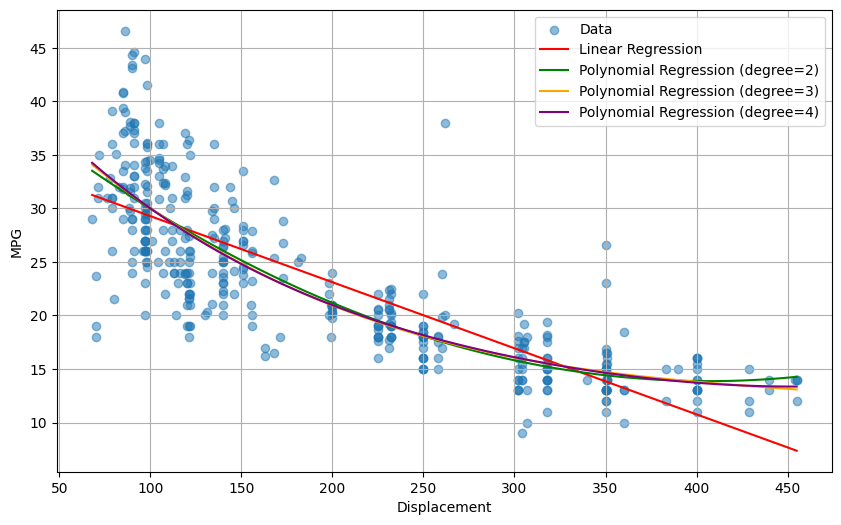

In [41]:
x_range =np.linspace(x.min(), x.max(), 100).reshape(-1,1)
plt.figure(figsize=(10,6))
plt.scatter(x,y, alpha=0.5,label='Data')

plt.plot(x_range, linear_model.predict(x_range),
color='red',
 label='Linear Regression')
colors=['green','orange','purple']

for degree, color in zip([2,3,4], colors):
    poly =PolynomialFeatures(degree)
    x_poly =poly.fit_transform(X)
    x_range_poly =poly.transform(x_range)

    poly_model =LinearRegression()
    poly_model.fit(x_poly, y)

    plt.plot(x_range,
             poly_model.predict(x_range_poly),
             color=color,
             label=f'Polynomial Regression (degree={degree})')
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.legend()
plt.grid()
plt.show()